# Week 3 Assignment : Customer Intelligence System using Clustering, Classification & Ensemble Learning

Submitted by: **Mahesh Shinde**

## 1. assignment details
---
This notebook builds a complete country intelligence system using the *Country Data* dataset. I apply **K-Means & DBSCAN** clustering to segment countries by socio-economic health indicators, then use those cluster labels to train and compare **Logistic Regression, Decision Tree, Random Forest, and XGBoost** classifiers, finishing with feature importance analysis and model persistence via Joblib.

## 2. Install & Import Libraries

In [26]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn xgboost joblib kagglehub

In [27]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

sns.set(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.max_columns', 20)

print("All libraries imported successfully.")

All libraries imported successfully.


## 3. Load Dataset
Load `Country-data.csv` and preview shape, columns and sample rows.

In [28]:
df = pd.read_csv('Country-data.csv')
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [29]:
df.tail()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310
166,Zambia,83.1,37.0,5.89,30.9,3280,14.00,52.0,5.40,1460


In [30]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (167, 10)
Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


## 4. Dataset Information
Quick look at data types, descriptive statistics, missing values and duplicates.

In [31]:
df.info()
df.describe().T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 12.5+ KB


,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


---
## 5. Data Cleaning
Standardize column names, enforce numeric dtypes, fill nulls with the median, and drop duplicates.


In [32]:
df.columns = [c.strip().lower() for c in df.columns]
numeric_cols = [c for c in df.columns if c != 'country']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

df = df.drop_duplicates().reset_index(drop=True)

print("Cleaned shape:", df.shape)
print("Missing values after cleaning:\n", df.isnull().sum())

Cleaned shape: (167, 10)
Missing values after cleaning:
 country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


## 6. Exploratory Data Analysis
Histograms, boxplots, correlation heatmap, pairplot and key feature distributions.

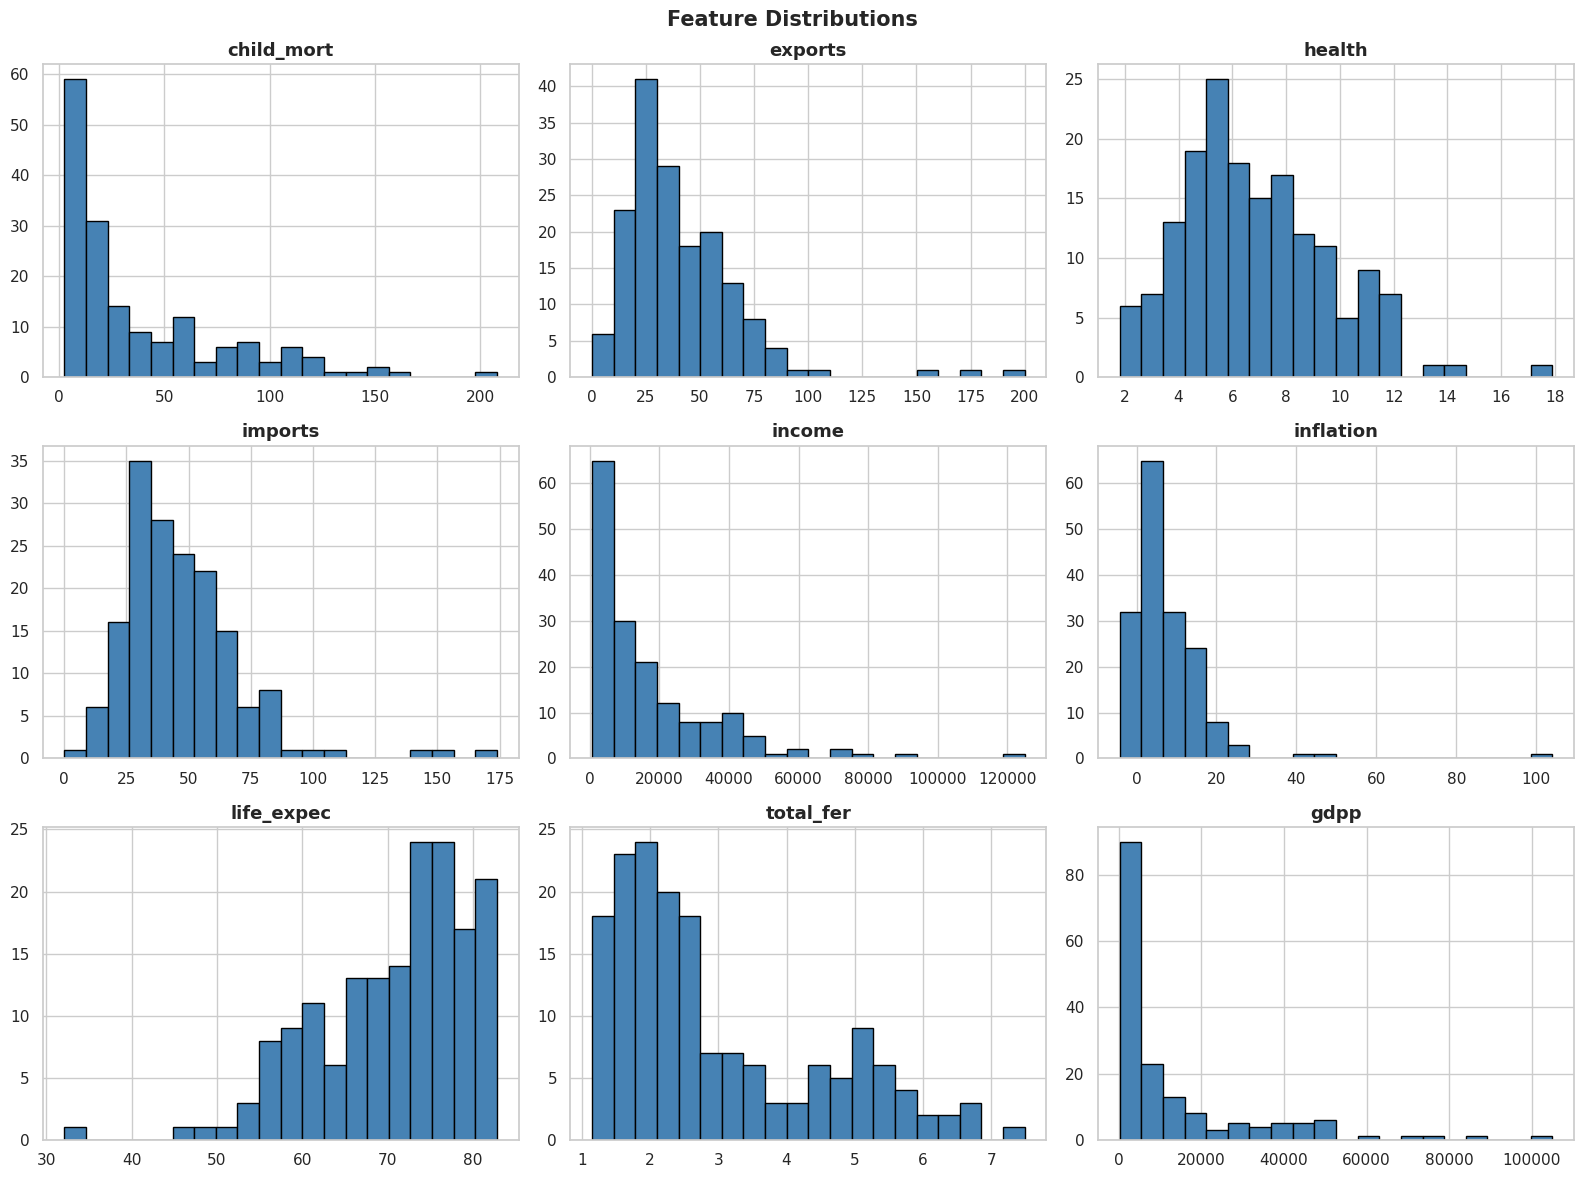

In [33]:
# Histogram of every numeric feature
df[numeric_cols].hist(figsize=(16, 12), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

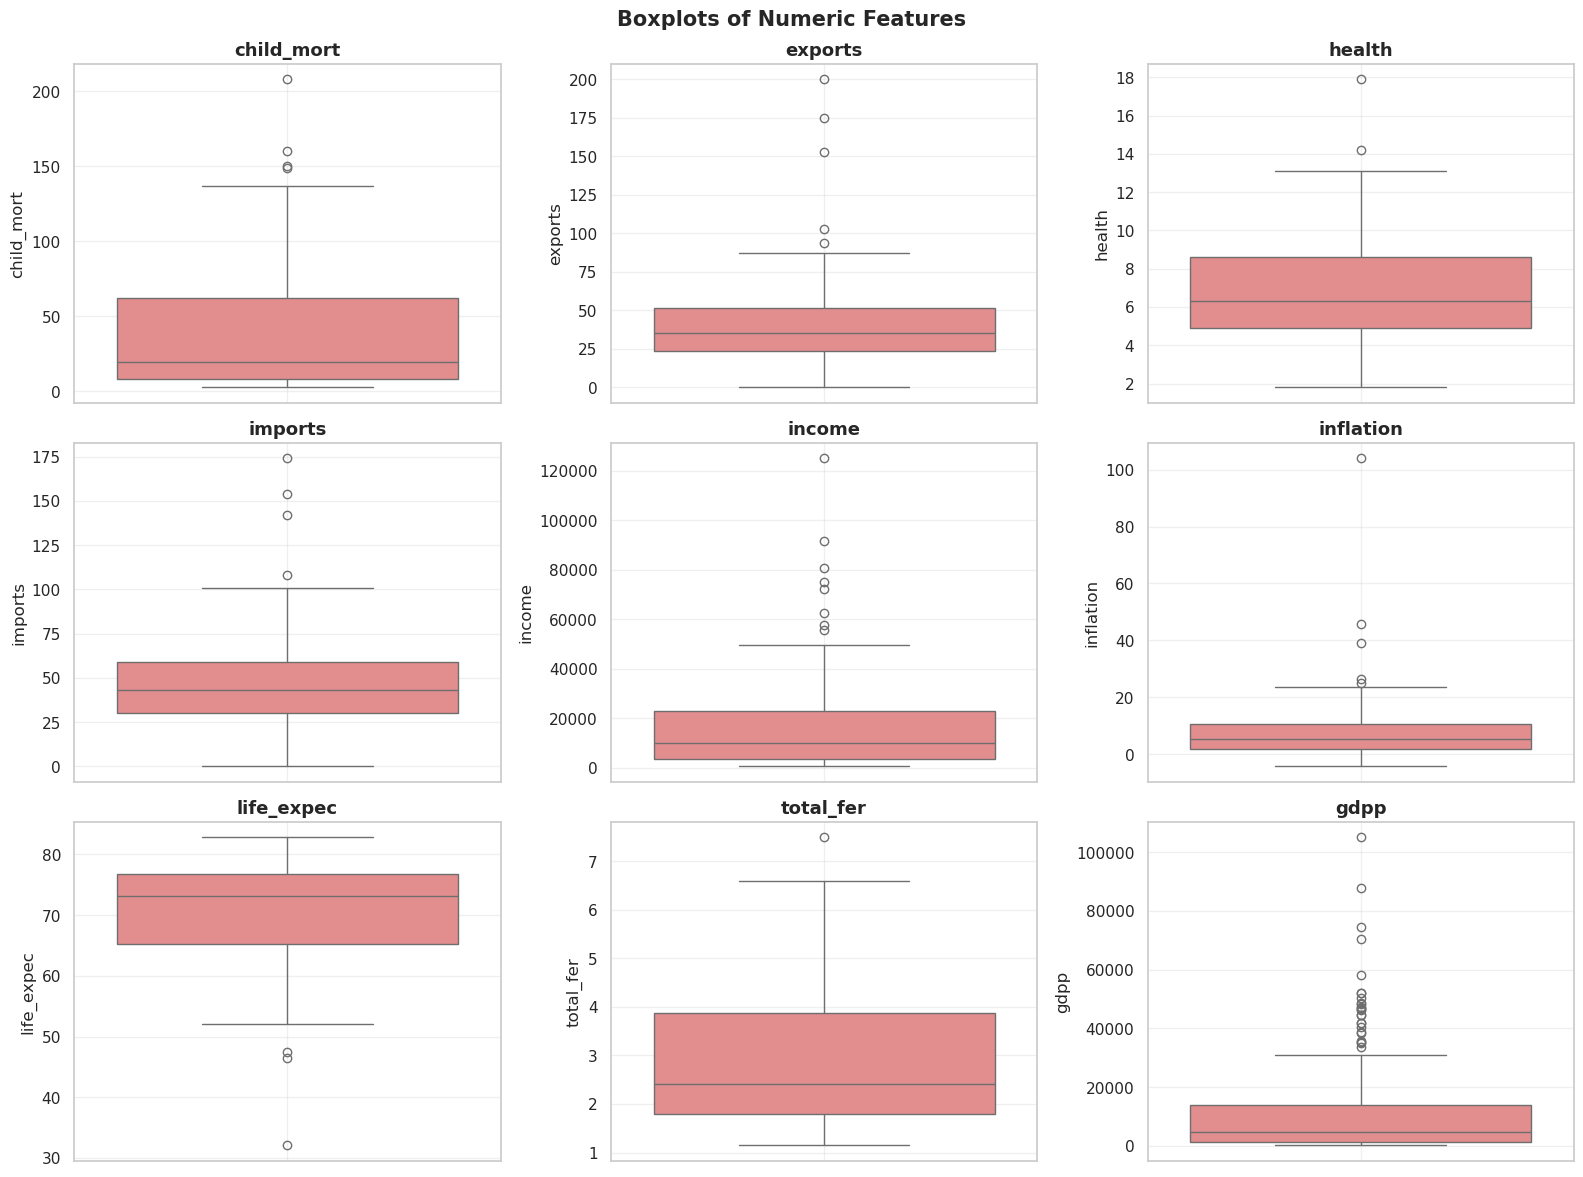

In [34]:
# Boxplots — spot outliers in every feature at a glance
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color='lightcoral')
    ax.set_title(col)
    ax.grid(alpha=0.3)
plt.suptitle('Boxplots of Numeric Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

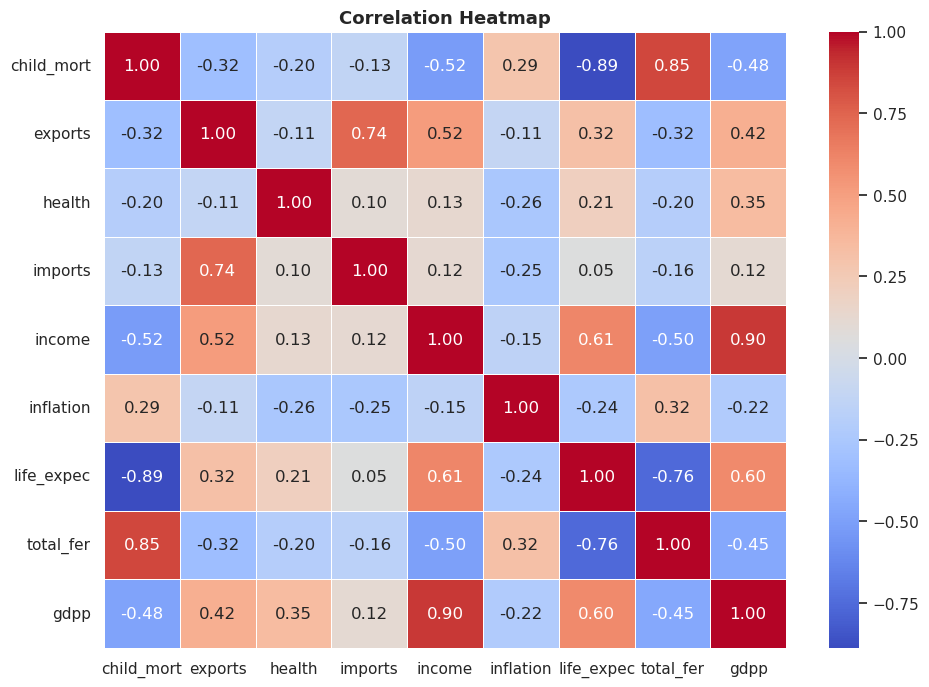

In [35]:
# Correlation heatmap
plt.figure(figsize=(11, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

`income` ↔ `gdpp` are strongly correlated; `child_mort` ↔ `total_fer` are high and both negatively correlate with `life_expec`.


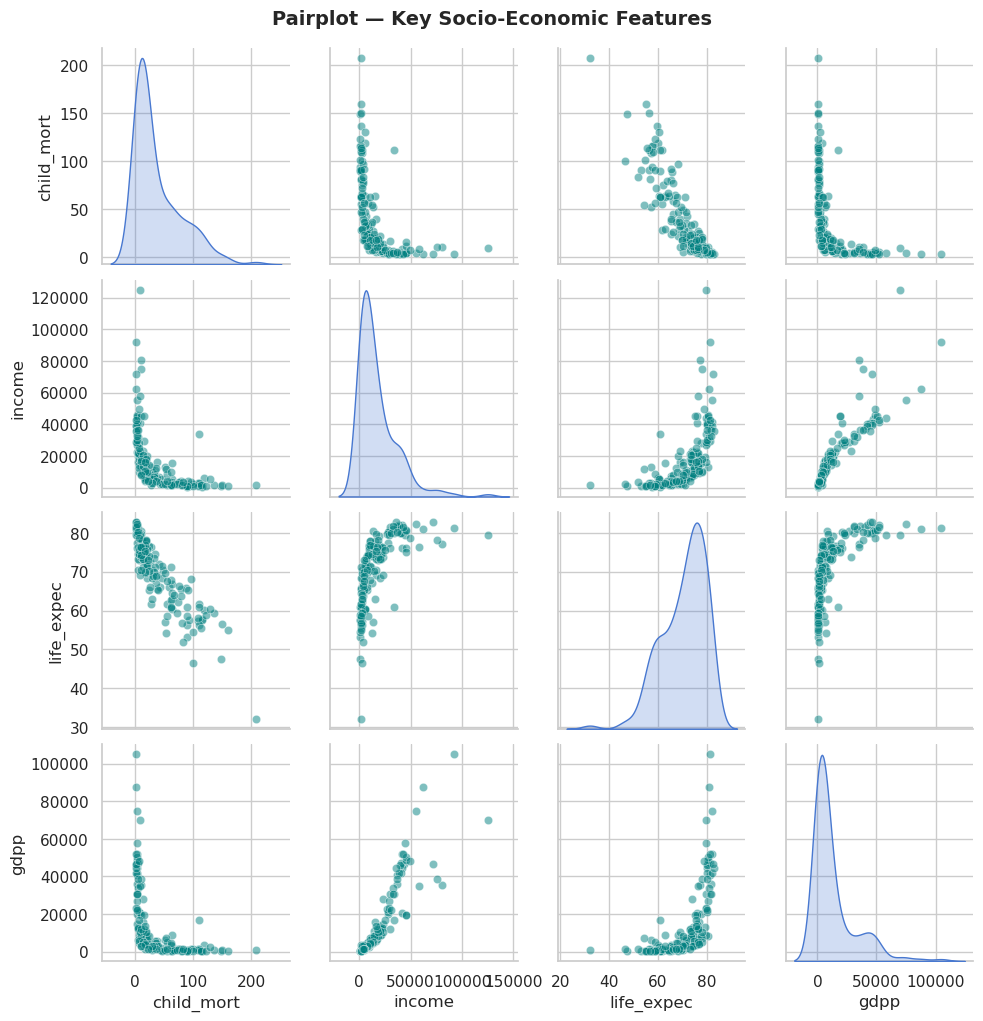

In [36]:
# Pairplot of the four most economically meaningful features
sns.pairplot(df[['child_mort', 'income', 'life_expec', 'gdpp']], diag_kind='kde',
             plot_kws={'alpha': 0.5, 'color': 'teal'})
plt.suptitle('Pairplot — Key Socio-Economic Features', y=1.02, fontsize=14, fontweight='bold')
plt.show()

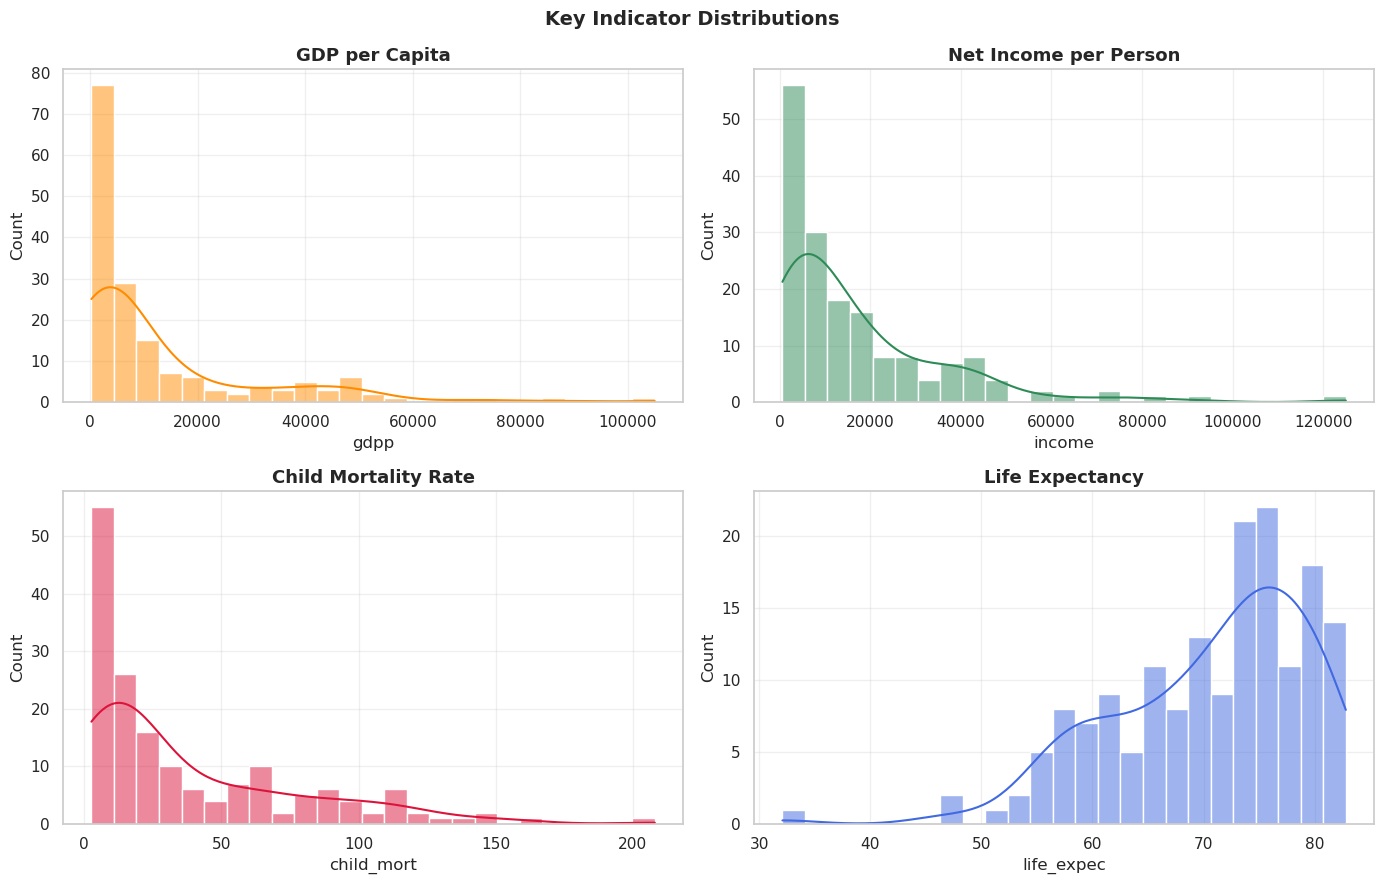

In [37]:
# GDP, Income, Child Mortality, Life Expectancy distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
pairs = [('gdpp','GDP per Capita','darkorange'), ('income','Net Income per Person','seagreen'),
         ('child_mort','Child Mortality Rate','crimson'), ('life_expec','Life Expectancy','royalblue')]
for ax, (col, label, color) in zip(axes.flatten(), pairs):
    sns.histplot(df[col], kde=True, color=color, bins=25, ax=ax)
    ax.set_title(label)
    ax.set_xlabel(col)
    ax.grid(alpha=0.3)
plt.suptitle('Key Indicator Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Feature Scaling
K-Means uses Euclidean distance — `StandardScaler` (mean=0, std=1) prevents high-magnitude features like `income` from dominating.

In [38]:
features = df.drop(columns=['country'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

print("Scaled matrix shape:", X_scaled.shape)

Scaled matrix shape: (167, 9)


## 8. K-Means Clustering
Use the Elbow Method and Silhouette Score to pick the optimal K, then train the final model.

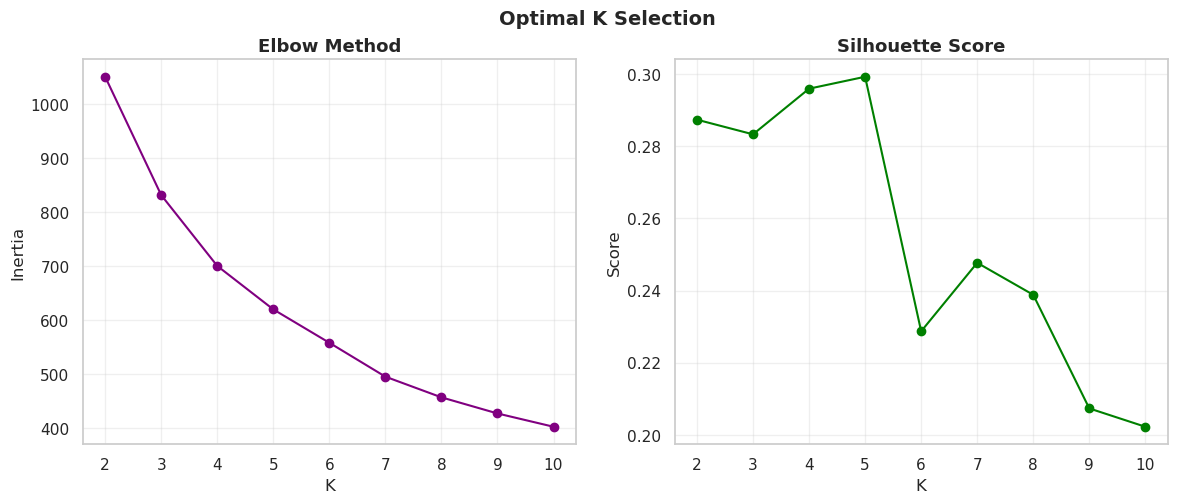

Optimal K (best silhouette): 5


In [39]:
# Elbow method
inertias, sil_scores, k_range = [], [], range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, 'o-', color='purple')
axes[0].set_title('Elbow Method'); axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia'); axes[0].grid(alpha=0.3)
axes[1].plot(list(k_range), sil_scores, 'o-', color='green')
axes[1].set_title('Silhouette Score'); axes[1].set_xlabel('K'); axes[1].set_ylabel('Score'); axes[1].grid(alpha=0.3)
plt.suptitle('Optimal K Selection', fontsize=14, fontweight='bold')
plt.show()

optimal_k = list(k_range)[int(np.argmax(sil_scores))]
print(f"Optimal K (best silhouette): {optimal_k}")

In [40]:
# Train final K-Means
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print("Cluster counts:\n", df['kmeans_cluster'].value_counts().sort_index())
print(f"\nSilhouette Score: {silhouette_score(X_scaled, df['kmeans_cluster']):.4f}")

Cluster counts:
 kmeans_cluster
0    84
1    47
2     3
3    32
4     1
Name: count, dtype: int64

Silhouette Score: 0.2993


## 9. DBSCAN Clustering
Density-based clustering; automatically detects clusters and flags noise points (`-1`).

In [41]:
# Grid search over hyperparameters
print(f"{'eps':>6} {'min_samples':>12} {'clusters':>9} {'noise':>7}")
for eps in [0.8, 1.0, 1.5, 2.0]:
    for ms in [3, 5, 10]:
        lbl = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_scaled)
        n_c = len(set(lbl)) - (1 if -1 in lbl else 0)
        n_n = (lbl == -1).sum()
        print(f"{eps:>6} {ms:>12} {n_c:>9} {n_n:>7}")

   eps  min_samples  clusters   noise
   0.8            3         8     112
   0.8            5         3     146
   0.8           10         0     167
   1.0            3         6      72
   1.0            5         3      94
   1.0           10         1     152
   1.5            3         2      25
   1.5            5         1      30
   1.5           10         1      38
   2.0            3         1      11
   2.0            5         1      15
   2.0           10         1      18


In [42]:
# Final DBSCAN model
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

print("DBSCAN cluster distribution (-1 = noise):")
print(df['dbscan_cluster'].value_counts().sort_index())

DBSCAN cluster distribution (-1 = noise):
dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64


**K-Means vs DBSCAN:** K-Means gives clean, balanced clusters ideal as classification targets. DBSCAN handles irregular shapes and exposes outliers but leaves some countries unassigned — less suitable as a supervised label source.

## 10. PCA Visualization
Reduce 9 features to 2 principal components and plot the K-Means clusters.

Variance explained: PC1=45.95%, PC2=17.18%


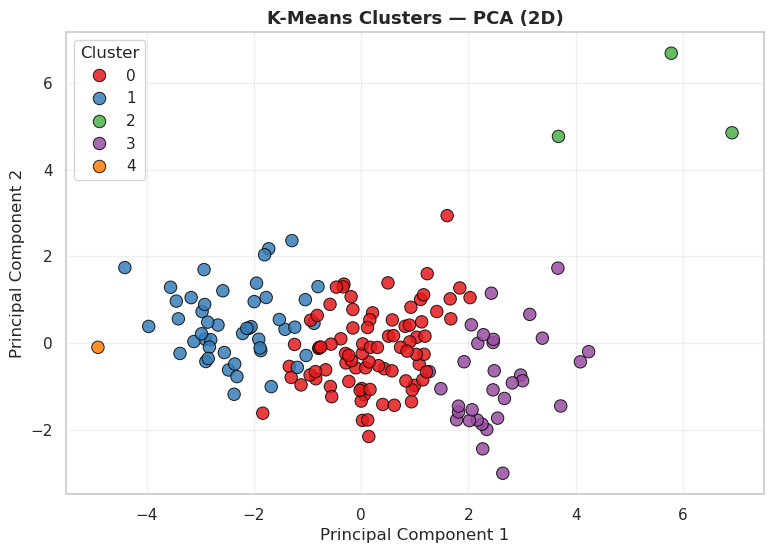

In [43]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Variance explained: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")

pca_df = pd.DataFrame({'PC1': X_pca[:, 0], 'PC2': X_pca[:, 1], 'Cluster': df['kmeans_cluster']})

plt.figure(figsize=(9, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster',
                palette='Set1', s=80, edgecolor='black', alpha=0.85)
plt.title('K-Means Clusters — PCA (2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(alpha=0.3)
plt.show()

## 11. Cluster Profiling


In [44]:
profile = df.groupby('kmeans_cluster')[numeric_cols].mean().round(2)
profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,21.61,40.98,6.17,47.52,12801.07,7.62,73.00,2.28,6581.81
1,90.79,29.66,6.46,43.68,3870.70,9.95,59.21,4.97,1900.26
2,4.13,176.00,6.79,156.67,64033.33,2.47,81.43,1.38,57566.67
3,5.18,46.12,9.09,40.58,44021.88,2.51,80.08,1.79,42118.75
4,130.00,25.30,5.07,17.40,5150.00,104.00,60.50,5.84,2330.00


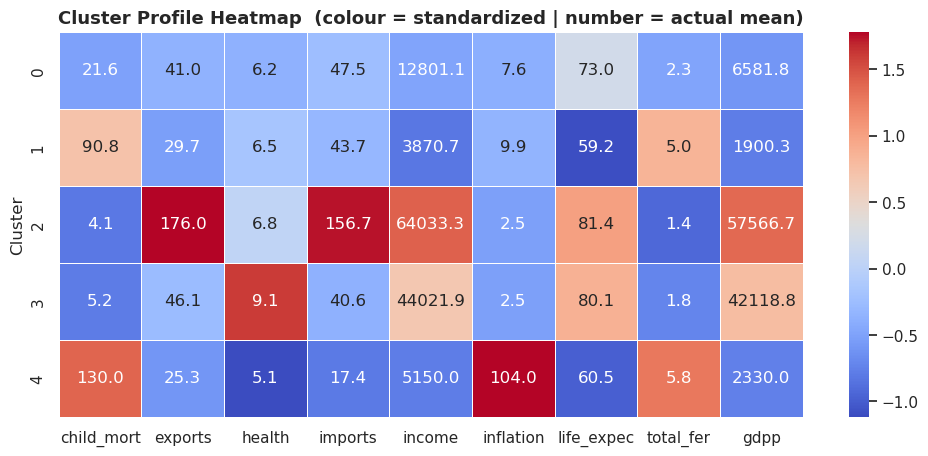

In [45]:
# Heatmap — colours show standardized values; numbers show actual means
norm = profile.apply(lambda x: (x - x.mean()) / x.std())
plt.figure(figsize=(12, 5))
sns.heatmap(norm, annot=profile, fmt='.1f', cmap='coolwarm', linewidths=0.5)
plt.title('Cluster Profile Heatmap  (colour = standardized | number = actual mean)')
plt.ylabel('Cluster')
plt.show()

Clusters with high `child_mort` + low `gdpp` → **underdeveloped**; high `gdpp` + low `child_mort` → **developed**; middle values → **developing**.

## 12. Business Insights


In [46]:
# Rank clusters by gdpp to assign development tier labels
tier_order = profile['gdpp'].sort_values().index.tolist()
tier_map = {tier_order[0]: 'Underdeveloped', tier_order[-1]: 'Developed'}
tier_map.update({k: 'Developing' for k in tier_order[1:-1]})
df['development_tier'] = df['kmeans_cluster'].map(tier_map)

print("Development tier distribution:")
print(df['development_tier'].value_counts())

Development tier distribution:
development_tier
Developing        117
Underdeveloped     47
Developed           3
Name: count, dtype: int64


In [47]:
# Countries most in need of aid (underdeveloped, sorted by gdpp ascending)
underdeveloped_cluster = tier_order[0]
aid_df = df[df['kmeans_cluster'] == underdeveloped_cluster].sort_values('gdpp').head(10)
aid_df[['country', 'child_mort', 'gdpp', 'income', 'life_expec']]

,country,child_mort,gdpp,income,life_expec
26,Burundi,93.6,231,764,57.7
88,Liberia,89.3,327,700,60.8
37,"Congo, Dem. Rep.",116.0,334,609,57.5
112,Niger,123.0,348,814,58.8
132,Sierra Leone,160.0,399,1220,55.0
93,Madagascar,62.2,413,1390,60.8
106,Mozambique,101.0,419,918,54.5
31,Central African Republic,149.0,446,888,47.5
94,Malawi,90.5,459,1030,53.1
50,Eritrea,55.2,482,1420,61.7


In [48]:
# Extremes across key indicators
extremes = {
    'Highest GDP per Capita': df.loc[df['gdpp'].idxmax(), ['country', 'gdpp']],
    'Highest Income': df.loc[df['income'].idxmax(), ['country', 'income']],
    'Highest Child Mortality': df.loc[df['child_mort'].idxmax(), ['country', 'child_mort']],
    'Highest Inflation': df.loc[df['inflation'].idxmax(), ['country', 'inflation']],
    'Highest Fertility Rate': df.loc[df['total_fer'].idxmax(), ['country', 'total_fer']],
    'Best Healthcare Spend': df.loc[df['health'].idxmax(), ['country', 'health']],
}
for label, row in extremes.items():
    print(f"{label}: {row.tolist()}")

Highest GDP per Capita: ['Luxembourg', np.int64(105000)]
Highest Income: ['Qatar', np.int64(125000)]
Highest Child Mortality: ['Haiti', np.float64(208.0)]
Highest Inflation: ['Nigeria', np.float64(104.0)]
Highest Fertility Rate: ['Niger', np.float64(7.49)]
Best Healthcare Spend: ['United States', np.float64(17.9)]


**Key findings:**
- Underdeveloped cluster countries have high child mortality, high fertility and low income — **priority targets for humanitarian aid**.
- Developed cluster countries lead on GDP, income, life expectancy and healthcare spending.
- `gdpp` and `income` are the clearest separators between tiers, consistent with the correlation heatmap.

## 13. Classification


In [50]:
# Drop non-feature columns
drop_cols = ['country', 'kmeans_cluster', 'dbscan_cluster', 'development_tier']
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df['kmeans_cluster']

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y,
#     test_size=0.2,
#     random_state=42,
#     stratify=y
# )

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

# Scale for Logistic Regression
clf_scaler = StandardScaler()
X_tr_sc = clf_scaler.fit_transform(X_train)
X_te_sc = clf_scaler.transform(X_test)

Train: (133, 9) | Test: (34, 9)


## 14. Train Multiple Classification Models
Train and evaluate Logistic Regression, Decision Tree, Random Forest and XGBoost.

In [52]:
model_results = {}

def evaluate_model(name, model, X_tr, X_te, use_scaled=False):
    Xtr = X_tr_sc if use_scaled else X_tr
    Xte = X_te_sc if use_scaled else X_te
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)

    scores = dict(
        Accuracy  = accuracy_score(y_test, preds),
        Precision = precision_score(y_test, preds, average='weighted', zero_division=0),
        Recall    = recall_score(y_test, preds, average='weighted', zero_division=0),
        F1        = f1_score(y_test, preds, average='weighted', zero_division=0),
    )
    model_results[name] = {**scores, 'model': model}

    print(f"── {name} ──")
    for k, v in scores.items():
        print(f"  {k:<12}: {v:.4f}")

    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix — {name}')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    print(classification_report(y_test, preds, zero_division=0))
    return model

── Logistic Regression ──
  Accuracy    : 0.9706
  Precision   : 0.9743
  Recall      : 0.9706
  F1          : 0.9712


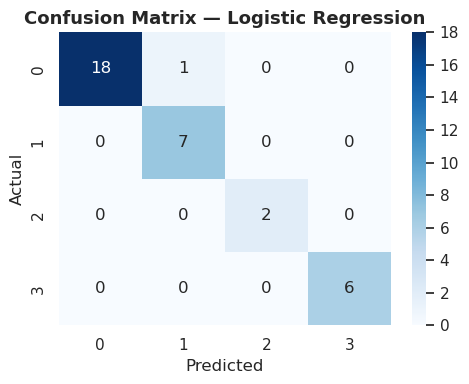

              precision    recall  f1-score   support

           0       1.00      0.95      0.97        19
           1       0.88      1.00      0.93         7
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         6

    accuracy                           0.97        34
   macro avg       0.97      0.99      0.98        34
weighted avg       0.97      0.97      0.97        34



In [53]:
log_reg = evaluate_model('Logistic Regression',
    LogisticRegression(max_iter=1000, random_state=42),
    X_train, X_test, use_scaled=True)

── Decision Tree ──
  Accuracy    : 0.9706
  Precision   : 0.9721
  Recall      : 0.9706
  F1          : 0.9698


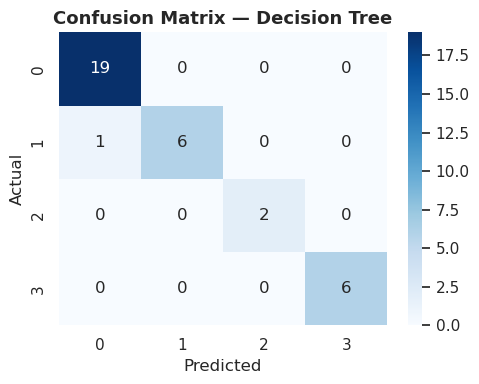

              precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       1.00      0.86      0.92         7
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         6

    accuracy                           0.97        34
   macro avg       0.99      0.96      0.97        34
weighted avg       0.97      0.97      0.97        34



In [54]:
dt_model = evaluate_model('Decision Tree',
    DecisionTreeClassifier(max_depth=6, random_state=42),
    X_train, X_test)

── Random Forest ──
  Accuracy    : 0.9412
  Precision   : 0.8971
  Recall      : 0.9412
  F1          : 0.9160


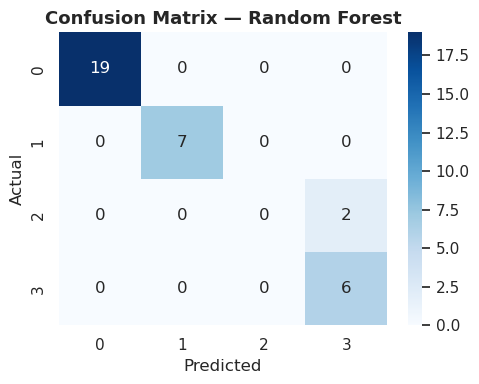

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00         7
           2       0.00      0.00      0.00         2
           3       0.75      1.00      0.86         6

    accuracy                           0.94        34
   macro avg       0.69      0.75      0.71        34
weighted avg       0.90      0.94      0.92        34



In [55]:
rf_model = evaluate_model('Random Forest',
    RandomForestClassifier(n_estimators=200, random_state=42),
    X_train, X_test)

── XGBoost ──
  Accuracy    : 0.9118
  Precision   : 0.8627
  Recall      : 0.9118
  F1          : 0.8838


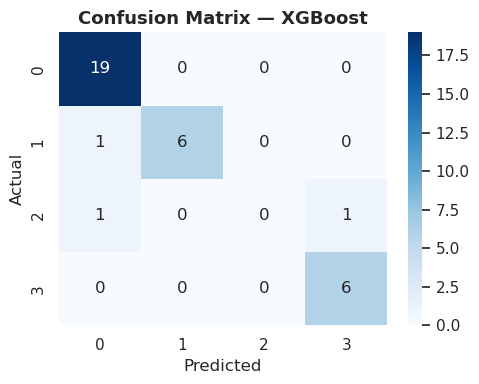

              precision    recall  f1-score   support

           0       0.90      1.00      0.95        19
           1       1.00      0.86      0.92         7
           2       0.00      0.00      0.00         2
           3       0.86      1.00      0.92         6

    accuracy                           0.91        34
   macro avg       0.69      0.71      0.70        34
weighted avg       0.86      0.91      0.88        34



In [56]:
xgb_model = evaluate_model('XGBoost',
    XGBClassifier(n_estimators=200, eval_metric='mlogloss',
                  use_label_encoder=False, random_state=42),
    X_train, X_test)

## 15. Ensemble Learning
Compare Decision Tree, Random Forest and XGBoost to show the advantage of ensemble methods.

In [57]:
cmp = pd.DataFrame(
    {name: {k: v for k, v in res.items() if k != 'model'}
     for name, res in model_results.items()}
).T.round(4).sort_values('Accuracy', ascending=False)
cmp

,Accuracy,Precision,Recall,F1
Logistic Regression,0.9706,0.9743,0.9706,0.9712
Decision Tree,0.9706,0.9721,0.9706,0.9698
Random Forest,0.9412,0.8971,0.9412,0.9160
XGBoost,0.9118,0.8627,0.9118,0.8838


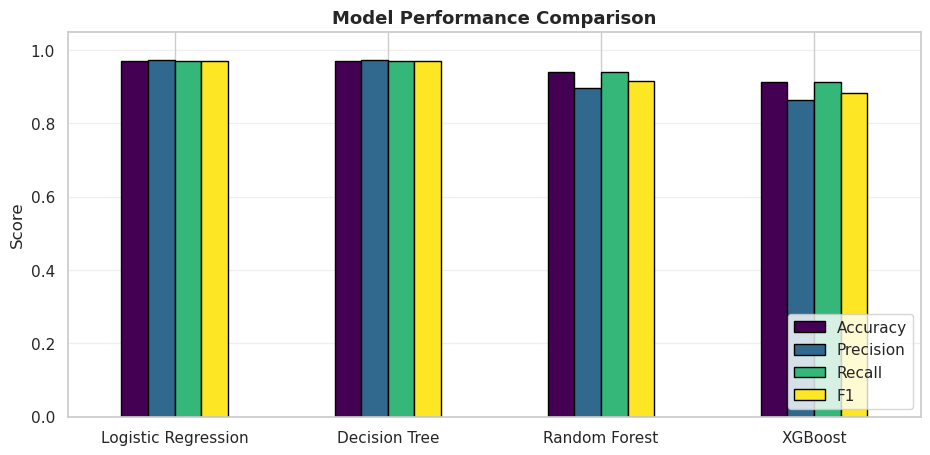

In [58]:
cmp[['Accuracy', 'Precision', 'Recall', 'F1']].plot(
    kind='bar', figsize=(11, 5), colormap='viridis', edgecolor='black')
plt.title('Model Performance Comparison')
plt.ylabel('Score'); plt.xticks(rotation=0); plt.ylim(0, 1.05)
plt.legend(loc='lower right'); plt.grid(alpha=0.3, axis='y')
plt.show()

**Reasons why ensemble algorithms win:** Overfitting is caused by a single Decision Tree. Random Forest algorithm (bagging technique) decreases variance by averaging multiple Decision Trees. XGBoost algorithm (boosting technique) decreases bias through sequential correction of errors.

## 16. Feature Importance
Inspect which features drive predictions in Random Forest and XGBoost.

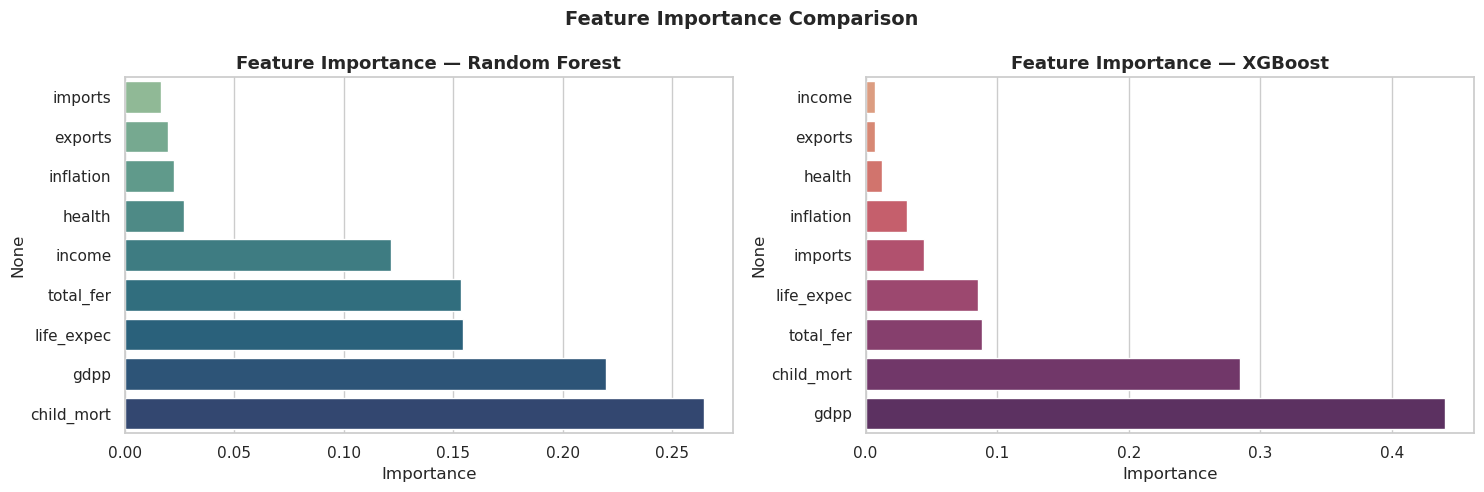

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, (model, title, palette) in zip(axes, [
    (rf_model,  'Random Forest', 'crest'),
    (xgb_model, 'XGBoost',       'flare')
]):
    imp = pd.Series(model.feature_importances_, index=X.columns).sort_values()
    sns.barplot(x=imp.values, y=imp.index, palette=palette, ax=ax)
    ax.set_title(f'Feature Importance — {title}')
    ax.set_xlabel('Importance')
plt.suptitle('Feature Importance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

`gdpp`, `income` and `child_mort` are the top predictors in both models - consistent with the cluster profiles and business insights.

## 17. Model Saving
Persist the scaler, Random Forest and XGBoost models with Joblib for future inference.

In [61]:
joblib.dump(clf_scaler, 'scaler.pkl')
joblib.dump(rf_model,  'random_forest_model.pkl')
joblib.dump(xgb_model, 'xgboost_model.pkl')

print("Saved: scaler.pkl | random_forest_model.pkl | xgboost_model.pkl")

Saved: scaler.pkl | random_forest_model.pkl | xgboost_model.pkl


## 18. Final Conclusion

| Item | Detail |
|---|---|
| Dataset | Country Data — 167 countries, 9 features |
| Clustering | K-Means (primary), DBSCAN (comparison) |
| Classification | Logistic Regression, Decision Tree, Random Forest, XGBoost |
| Best clustering model | **K-Means** — highest silhouette score, clean balanced clusters |
| Best classification model | **Random Forest / XGBoost** — highest accuracy & F1 |
| Top predictive features | `gdpp`, `income`, `child_mort` |


## 19. Cluster Dashboard
Summary table and bar charts showing average socio-economic indicators per cluster.

In [62]:
dashboard = df.groupby('kmeans_cluster').agg(
    Countries      = ('country',    'count'),
    Avg_GDP        = ('gdpp',       'mean'),
    Avg_Income     = ('income',     'mean'),
    Avg_Child_Mort = ('child_mort', 'mean'),
    Avg_Life_Expec = ('life_expec', 'mean'),
    Avg_Inflation  = ('inflation',  'mean'),
).round(2)
dashboard

,Countries,Avg_GDP,Avg_Income,Avg_Child_Mort,Avg_Life_Expec,Avg_Inflation
kmeans_cluster,,,,,,
0,84,6581.81,12801.07,21.61,73.00,7.62
1,47,1900.26,3870.70,90.79,59.21,9.95
2,3,57566.67,64033.33,4.13,81.43,2.47
3,32,42118.75,44021.88,5.18,80.08,2.51
4,1,2330.00,5150.00,130.00,60.50,104.00


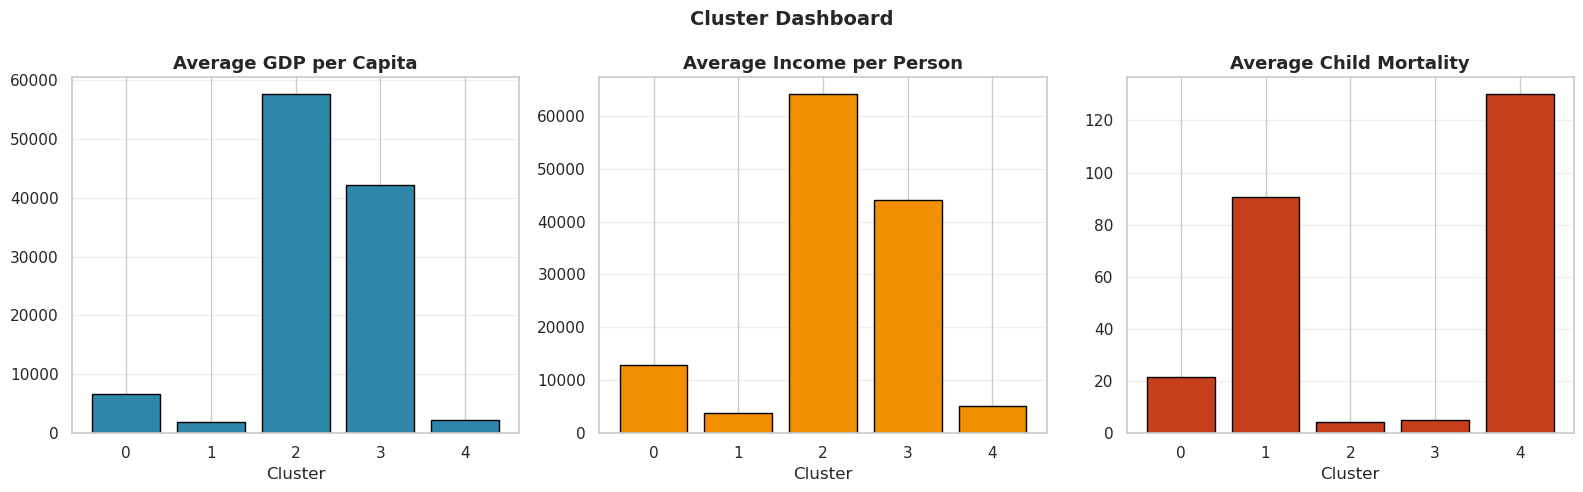

Notebook completed successfully.


In [63]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = [
    ('Avg_GDP',        'Average GDP per Capita',     '#2E86AB'),
    ('Avg_Income',     'Average Income per Person',  '#F18F01'),
    ('Avg_Child_Mort', 'Average Child Mortality',    '#C73E1D'),
]
for ax, (col, label, color) in zip(axes, metrics):
    ax.bar(dashboard.index.astype(str), dashboard[col], color=color, edgecolor='black')
    ax.set_title(label); ax.set_xlabel('Cluster'); ax.grid(alpha=0.3, axis='y')

plt.suptitle('Cluster Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Notebook completed successfully.")

#### Submitted By : 
Mahesh Shinde (Sanjivani College of Engineering)